# Conductor.fun Inventory Dataset — Comprehensive EDA & Readiness Report

Full data-quality and statistics pass across all four inventory categories
(Locomotives, Passenger Train Cars, Freight Cars, Automobiles) before using
this dataset to train the visual search image classifier.

**What this notebook covers:**
1. Load & validate the manifest (`products_index.csv`, `failed_downloads.csv`)
2. Build a master image-level dataframe across all categories
3. Combined statistics (all 4 categories together)
4. Per-category statistics (each of the 4, separately)
5. Class balance (images per `products_id`)
6. Corrupt / unreadable image detection
7. Image format, resolution, aspect ratio, file size analysis
8. Duplicate image detection (within and across categories)
9. Naming sanity checks (duplicate names, likely look-alike pairs)
10. Failed downloads analysis
11. Azure Custom Vision readiness checks (format/size/resolution limits)
12. Visual sample grids per category
13. Final readiness summary + exportable clean manifest

**Dataset paths:**
```
/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/
  ├── Automobiles/
  ├── Locomotives/
  ├── Freight Cars/
  ├── Passenger Train Cars/
  ├── products_index.csv
  └── failed_downloads.csv
```

## 0. Setup & Configuration

In [1]:
import os
import re
import hashlib
import warnings
from collections import Counter, defaultdict
from difflib import SequenceMatcher

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
DATASET_ROOT = "/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images"

CATEGORY_DIRS = {
    "Locomotives": os.path.join(DATASET_ROOT, "Locomotives"),
    "Passenger Train Cars": os.path.join(DATASET_ROOT, "Passenger Train Cars"),
    "Freight Cars": os.path.join(DATASET_ROOT, "Freight Cars"),
    "Automobiles": os.path.join(DATASET_ROOT, "Automobiles"),
}

PRODUCTS_INDEX_CSV = os.path.join(DATASET_ROOT, "products_index.csv")
FAILED_DOWNLOADS_CSV = os.path.join(DATASET_ROOT, "failed_downloads.csv")

VALID_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".gif"}

# Azure Custom Vision technical limits — used later for readiness checks
AZURE_MIN_DIMENSION = 256        # px, shorter side recommended minimum
AZURE_MAX_FILE_SIZE_MB = 6
AZURE_MIN_RECOMMENDED_IMAGES_PER_TAG = 15   # Microsoft's general guidance for solid accuracy
AZURE_ABSOLUTE_MIN_IMAGES_PER_TAG = 5       # Custom Vision's hard minimum to train a tag at all

for name, path in CATEGORY_DIRS.items():
    status = "OK" if os.path.isdir(path) else "MISSING"
    print(f"{name:24s} -> {path}  [{status}]")

print()
print("products_index.csv:", "OK" if os.path.isfile(PRODUCTS_INDEX_CSV) else "MISSING")
print("failed_downloads.csv:", "OK" if os.path.isfile(FAILED_DOWNLOADS_CSV) else "MISSING (this is fine if nothing failed)")

Locomotives              -> /kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives  [OK]
Passenger Train Cars     -> /kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Passenger Train Cars  [OK]
Freight Cars             -> /kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Freight Cars  [OK]
Automobiles              -> /kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Automobiles  [OK]

products_index.csv: OK
failed_downloads.csv: OK


## 1. Load the Manifest Files

`products_index.csv` is the authoritative list of every product the scraper found on the
live site (regardless of whether its image downloaded successfully). `failed_downloads.csv`
lists anything that failed validation and was intentionally excluded from the dataset.

In [3]:
products_df = pd.read_csv(PRODUCTS_INDEX_CSV, dtype={"products_id": str})
products_df["products_id"] = products_df["products_id"].str.strip()
print(f"products_index.csv: {len(products_df)} rows")
products_df.head(10)

products_index.csv: 838 rows


,products_id,catalog_name,category
0,185,Frisco E8,Locomotives
1,193,Pennsylvania T1,Locomotives
2,213,The Texas Special - 1500 James Fannin,Passenger Train Cars
3,214,The Texas Special - 1502 Wiliam Traulis,Passenger Train Cars
4,215,The Texas Special - 1504 James Bowie,Passenger Train Cars
5,947,Maintenace car I,Freight Cars
6,949,Rio Grande 3827,Freight Cars
7,950,Delton Doozie 60,Locomotives
8,951,Rio Grande 746,Freight Cars
9,952,Rio Grande 5828,Freight Cars


In [4]:
print("Row count per category (as listed in products_index.csv):")
products_df["category"].value_counts()

Row count per category (as listed in products_index.csv):


category
Freight Cars            334
Locomotives             312
Passenger Train Cars    171
Automobiles              21
Name: count, dtype: int64

In [5]:
if os.path.isfile(FAILED_DOWNLOADS_CSV):
    failed_df = pd.read_csv(FAILED_DOWNLOADS_CSV, dtype={"products_id": str})
    print(f"failed_downloads.csv: {len(failed_df)} rows")
    display(failed_df)
else:
    failed_df = pd.DataFrame(columns=["products_id", "catalog_name", "category", "image_url_or_reason"])
    print("No failed_downloads.csv found — assuming zero failures.")

failed_downloads.csv: 11 rows


,products_id,catalog_name,category,image_url_or_reason
0,1574,LGB Box Cars (2) P&O + LGB 5057,Locomotives,images/LGB Box Cars (2) P&O + LGB 5057.jpg
1,1541,LGB diesel-locomotive Nichtraucher 2,Locomotives,images/LGB diesel-locomotive Nichtraucher 2.jpg
2,1543,LGB Rottenfahrzeug Nur für Nebenstrecken,Locomotives,images/LGB Rottenfahrzeug Nur für Nebenstrecken.jpg
3,1709,#326 C-16 DENVER & RIO GRANDE,Locomotives,bmz_cache/3/326-c-16-denver-rio-grandejpg.image.280x210.jpg
4,1858,F-3 A PWR comp texas special,Locomotives,images/F-3-A-PWR-comp-texas-special.jpg
5,1857,F.M. Trainmaster post war N.J.C. 6-18321,Locomotives,images/FM-Trainmaster-post-war-NJC-6-18321.jpg
6,1732,Lionel Classics Passenger Car Set Piece 1,Locomotives,images/Lionel-Classics-Passenger-Car-Set-1.jpg
7,1787,Norfork Southern Dash 8 40-C 6-18213,Locomotives,bmz_cache/n/norfork-southern-dash-8-40-c-6-18213jpg.image.280x210.jpg
8,1772,Santa De Dash 8 40-B 6-18212,Locomotives,images/Santa-De-Dash-8-40-B-6-18212.jpg
9,1540,LGB diesel-locomotive Nichtraucher 2,Freight Cars,images/LGB diesel-locomotive Nichtraucher 2.jpg


In [6]:
if len(failed_df):
    print("Failed downloads per category:")
    print(failed_df["category"].value_counts())
    print()
    print(f"Total failed: {len(failed_df)} out of {len(products_df)} listed products "
          f"({len(failed_df)/len(products_df)*100:.1f}%)")

Failed downloads per category:
category
Locomotives     9
Freight Cars    2
Name: count, dtype: int64

Total failed: 11 out of 838 listed products (1.3%)


## 2. Build the Master Image-Level Dataframe

Walks every category folder on disk and records every actual image file found,
regardless of what the CSV says — this is the ground truth of what's physically
present and usable for training.

In [7]:
records = []

for category, cat_path in CATEGORY_DIRS.items():
    if not os.path.isdir(cat_path):
        continue
    for products_id in sorted(os.listdir(cat_path)):
        item_path = os.path.join(cat_path, products_id)
        if not os.path.isdir(item_path):
            continue
        for fname in sorted(os.listdir(item_path)):
            ext = os.path.splitext(fname)[1].lower()
            if ext in VALID_EXTS:
                records.append({
                    "category": category,
                    "products_id": products_id,
                    "filename": fname,
                    "path": os.path.join(item_path, fname),
                })

images_df = pd.DataFrame(records)
print(f"Total image files found on disk: {len(images_df)}")
print(f"Total unique (category, products_id) folders with >=1 image: {images_df.groupby(['category','products_id']).ngroups}")
images_df.head(10)

Total image files found on disk: 827
Total unique (category, products_id) folders with >=1 image: 827


,category,products_id,filename,path
0,Locomotives,1030,1030.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1030/1...
1,Locomotives,1031,1031.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1031/1...
2,Locomotives,1035,1035.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1035/1...
3,Locomotives,1044,1044.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1044/1...
4,Locomotives,1048,1048.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1048/1...
5,Locomotives,1049,1049.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1049/1...
6,Locomotives,1060,1060.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1060/1...
7,Locomotives,1071,1071.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1071/1...
8,Locomotives,1072,1072.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1072/1...
9,Locomotives,1073,1073.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1073/1...


In [8]:
# Merge in the catalog name from products_index.csv for readability
images_df = images_df.merge(
    products_df[["products_id", "catalog_name", "category"]],
    on=["products_id", "category"], how="left"
)

missing_name = images_df["catalog_name"].isna().sum()
if missing_name:
    print(f"⚠️ {missing_name} image(s) have a products_id/category combo not found in products_index.csv — worth investigating.")
else:
    print("✅ Every image on disk matches a row in products_index.csv.")

images_df.head(10)

✅ Every image on disk matches a row in products_index.csv.


,category,products_id,filename,path,catalog_name
0,Locomotives,1030,1030.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1030/1...,41. Pacific Lumber Company
1,Locomotives,1031,1031.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1031/1...,42. Pacific Lumber Company Climax Locomotive #PLMC No.2
2,Locomotives,1035,1035.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1035/1...,46. Pennsylvania 889
3,Locomotives,1044,1044.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1044/1...,72. LIONEL I-384-E
4,Locomotives,1048,1048.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1048/1...,75. 2-400E locomotiv + tender
5,Locomotives,1049,1049.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1049/1...,76. Lionel I-400E Blue Comet Steam
6,Locomotives,1060,1060.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1060/1...,87. Lionel 2-390-E locomotive & tender
7,Locomotives,1071,1071.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1071/1...,98. Lionel 1-381E
8,Locomotives,1072,1072.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1072/1...,99. Locomotive 6 B-3-C
9,Locomotives,1073,1073.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1073/1...,100. Lionel 1-408E


## 3. Combined Overview — All 4 Categories Together

High-level numbers across the entire dataset before breaking things down by category.

In [9]:
total_listed = len(products_df)
total_images_on_disk = len(images_df)
total_items_with_images = images_df.groupby(['category','products_id']).ngroups
total_items_zero_images = total_listed - total_items_with_images

summary_combined = pd.DataFrame({
    "Metric": [
        "Products listed in products_index.csv",
        "Products with >=1 image on disk",
        "Products with ZERO images on disk",
        "Total image files on disk",
        "Avg images per product (with >=1 image)",
        "Rows in failed_downloads.csv",
    ],
    "Value": [
        total_listed,
        total_items_with_images,
        total_items_zero_images,
        total_images_on_disk,
        round(total_images_on_disk / total_items_with_images, 2) if total_items_with_images else 0,
        len(failed_df),
    ]
})
summary_combined

,Metric,Value
0,Products listed in products_index.csv,838.0
1,Products with >=1 image on disk,827.0
2,Products with ZERO images on disk,11.0
3,Total image files on disk,827.0
4,Avg images per product (with >=1 image),1.0
5,Rows in failed_downloads.csv,11.0


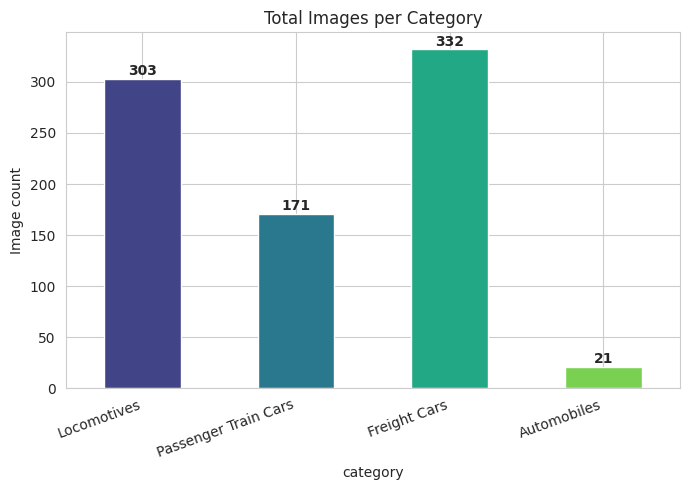

In [10]:
plt.figure(figsize=(7,5))
counts_by_cat = images_df.groupby('category')['path'].count().reindex(CATEGORY_DIRS.keys())
ax = counts_by_cat.plot(kind='bar', color=sns.color_palette('viridis', 4))
plt.title('Total Images per Category')
plt.ylabel('Image count')
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(counts_by_cat.values):
    ax.text(i, v + max(counts_by_cat.values)*0.01, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Per-Category Breakdown

Same core numbers as Section 3, but split out individually for each of the 4
categories — this is what actually matters when deciding readiness category by
category (e.g. training Locomotives first, per the phased plan).

In [11]:
per_category_rows = []

for category in CATEGORY_DIRS.keys():
    listed = (products_df["category"] == category).sum()
    cat_images = images_df[images_df["category"] == category]
    with_images = cat_images["products_id"].nunique()
    n_images = len(cat_images)
    n_failed = (failed_df["category"] == category).sum() if len(failed_df) else 0

    per_category_rows.append({
        "Category": category,
        "Listed": listed,
        "With >=1 Image": with_images,
        "Zero Images": listed - with_images,
        "Total Images": n_images,
        "Avg Images/Item": round(n_images / with_images, 2) if with_images else 0,
        "Failed Downloads": n_failed,
    })

per_category_df = pd.DataFrame(per_category_rows)
per_category_df

,Category,Listed,With >=1 Image,Zero Images,Total Images,Avg Images/Item,Failed Downloads
0,Locomotives,312,303,9,303,1.0,9
1,Passenger Train Cars,171,171,0,171,1.0,0
2,Freight Cars,334,332,2,332,1.0,2
3,Automobiles,21,21,0,21,1.0,0


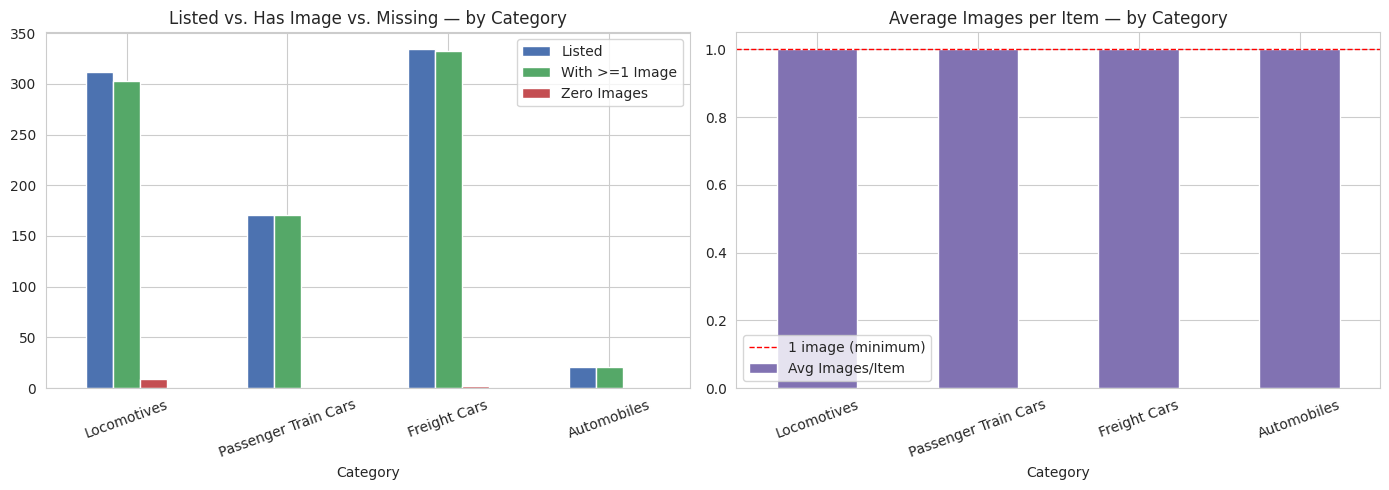

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

per_category_df.set_index('Category')[['Listed','With >=1 Image','Zero Images']].plot(
    kind='bar', ax=axes[0], color=['#4C72B0','#55A868','#C44E52'])
axes[0].set_title('Listed vs. Has Image vs. Missing — by Category')
axes[0].tick_params(axis='x', rotation=20)

per_category_df.set_index('Category')['Avg Images/Item'].plot(
    kind='bar', ax=axes[1], color='#8172B2')
axes[1].set_title('Average Images per Item — by Category')
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(1, color='red', linestyle='--', linewidth=1, label='1 image (minimum)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Class Balance — Images per Product (`products_id`)

This is the single most important factor for training accuracy. A product with only
1 training image will generalize far worse to a real phone photo than one with
several angles.

In [13]:
images_per_product = images_df.groupby(['category','products_id']).size().rename('n_images').reset_index()

print('Combined (all categories) — images-per-product distribution:')
print(images_per_product['n_images'].describe())
print()
print('Count of products by number of images:')
print(images_per_product['n_images'].value_counts().sort_index())

Combined (all categories) — images-per-product distribution:
count    827.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: n_images, dtype: float64

Count of products by number of images:
n_images
1    827
Name: count, dtype: int64


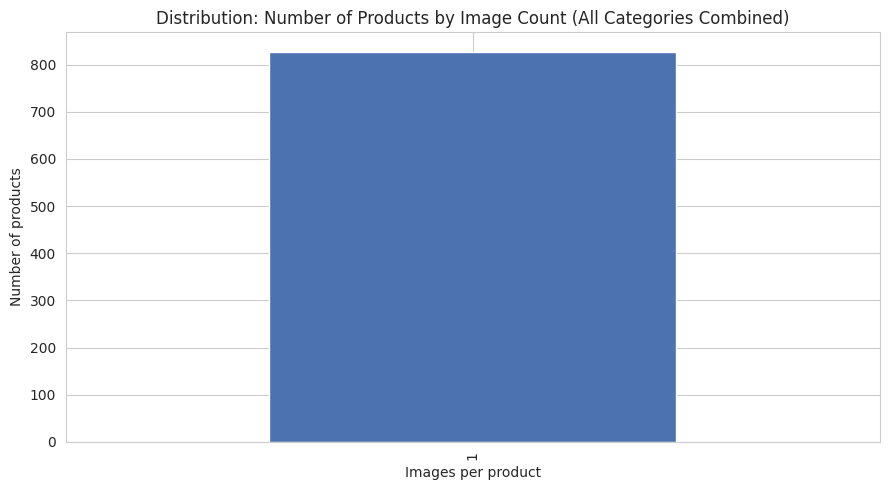

In [14]:
plt.figure(figsize=(9,5))
dist = images_per_product['n_images'].value_counts().sort_index()
ax = dist.plot(kind='bar', color='#4C72B0')
plt.title('Distribution: Number of Products by Image Count (All Categories Combined)')
plt.xlabel('Images per product')
plt.ylabel('Number of products')
plt.tight_layout()
plt.show()

In [15]:
single_image_products = images_per_product[images_per_product['n_images'] == 1]
pct_single = len(single_image_products) / len(images_per_product) * 100
print(f"Products with exactly 1 image: {len(single_image_products)} / {len(images_per_product)} ({pct_single:.1f}%)")
print()
print('Breakdown of single-image products by category:')
single_image_products['category'].value_counts()

Products with exactly 1 image: 827 / 827 (100.0%)

Breakdown of single-image products by category:


category
Freight Cars            332
Locomotives             303
Passenger Train Cars    171
Automobiles              21
Name: count, dtype: int64

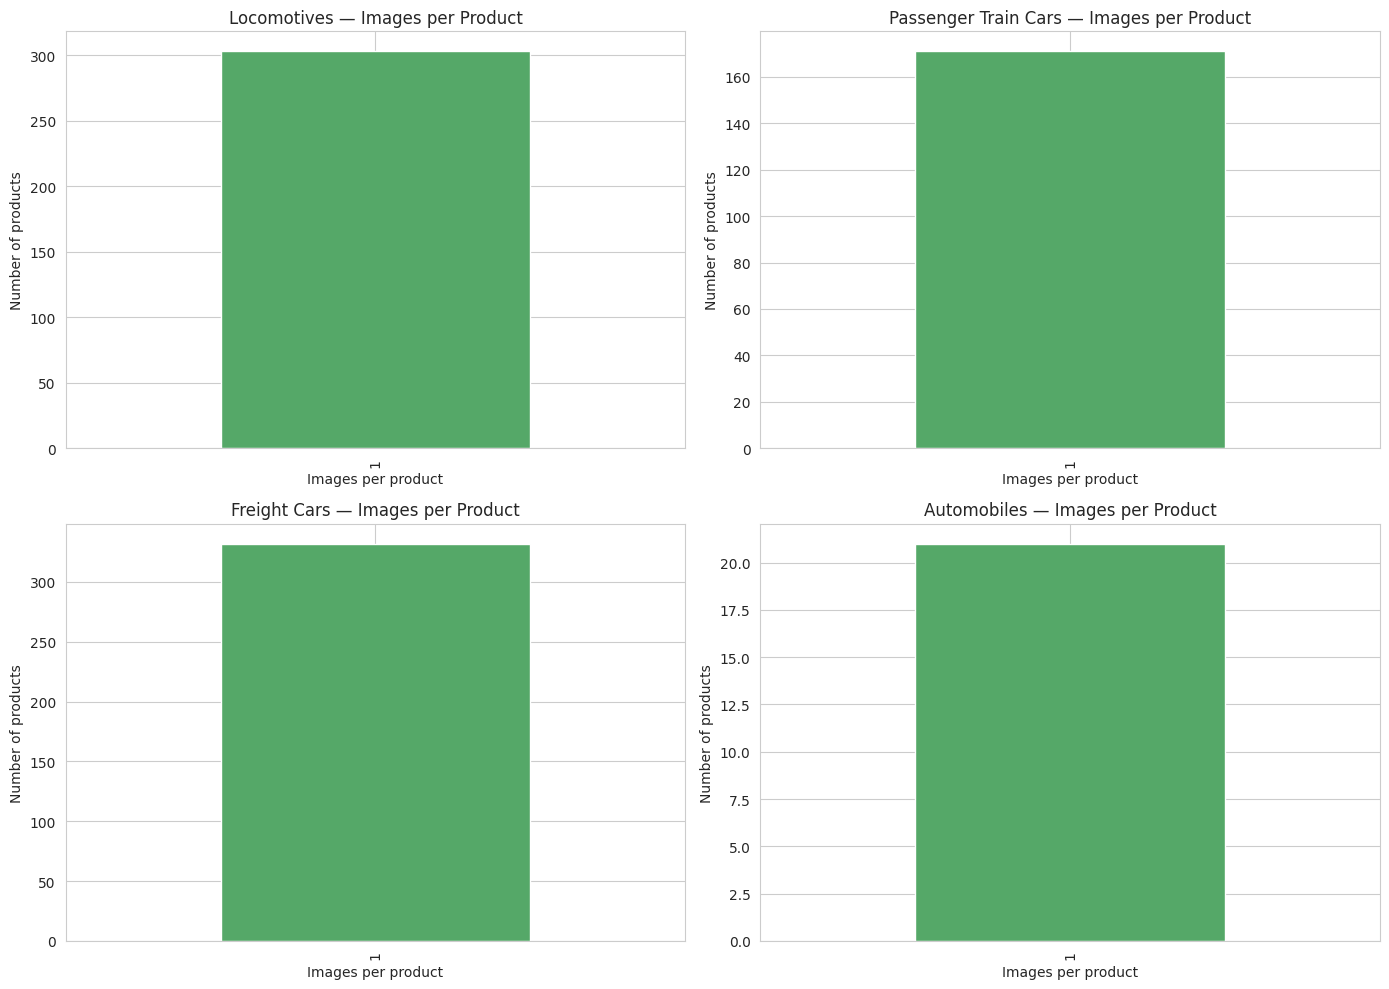

In [16]:
# Per-category class balance side-by-side
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for ax, category in zip(axes, CATEGORY_DIRS.keys()):
    cat_dist = images_per_product[images_per_product['category']==category]['n_images'].value_counts().sort_index()
    cat_dist.plot(kind='bar', ax=ax, color='#55A868')
    ax.set_title(f'{category} — Images per Product')
    ax.set_xlabel('Images per product')
    ax.set_ylabel('Number of products')

plt.tight_layout()
plt.show()

In [17]:
# Products below Azure's absolute minimum (5) and below the recommended minimum (15)
below_absolute_min = images_per_product[images_per_product['n_images'] < AZURE_ABSOLUTE_MIN_IMAGES_PER_TAG]
below_recommended = images_per_product[images_per_product['n_images'] < AZURE_MIN_RECOMMENDED_IMAGES_PER_TAG]

print(f"Products below Azure's absolute minimum ({AZURE_ABSOLUTE_MIN_IMAGES_PER_TAG} images/tag): "
      f"{len(below_absolute_min)} / {len(images_per_product)} ({len(below_absolute_min)/len(images_per_product)*100:.1f}%)")
print(f"Products below Microsoft's RECOMMENDED minimum ({AZURE_MIN_RECOMMENDED_IMAGES_PER_TAG} images/tag): "
      f"{len(below_recommended)} / {len(images_per_product)} ({len(below_recommended)/len(images_per_product)*100:.1f}%)")
print()
print("NOTE: Azure Custom Vision can still train tags below its absolute minimum in many project types,")
print("but accuracy on those specific tags should be expected to be materially weaker.")

Products below Azure's absolute minimum (5 images/tag): 827 / 827 (100.0%)
Products below Microsoft's RECOMMENDED minimum (15 images/tag): 827 / 827 (100.0%)

NOTE: Azure Custom Vision can still train tags below its absolute minimum in many project types,
but accuracy on those specific tags should be expected to be materially weaker.


## 6. Corrupt / Unreadable Image Check

Opens and verifies every single image file with Pillow. Anything that fails is
excluded from all downstream analysis (and should be excluded from training).

In [18]:
corrupt_records = []
valid_records = []

for _, row in images_df.iterrows():
    path = row['path']
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:  # re-open — verify() invalidates the handle
            width, height = img.size
            fmt = img.format
            mode = img.mode
        size_kb = os.path.getsize(path) / 1024
        valid_records.append({**row.to_dict(), 'width': width, 'height': height,
                               'format': fmt, 'mode': mode, 'size_kb': size_kb})
    except Exception as e:
        corrupt_records.append({**row.to_dict(), 'error': str(e)})

valid_df = pd.DataFrame(valid_records)
corrupt_df = pd.DataFrame(corrupt_records)

print(f"Checked: {len(images_df)} images")
print(f"Valid:   {len(valid_df)}")
print(f"Corrupt: {len(corrupt_df)}")

Checked: 827 images
Valid:   827
Corrupt: 0


In [19]:
if len(corrupt_df):
    print('⚠️ Corrupt/unreadable files found:')
    display(corrupt_df[['category','products_id','filename','error']])
else:
    print('✅ No corrupt or unreadable images found across the entire dataset.')

✅ No corrupt or unreadable images found across the entire dataset.


In [21]:
if len(corrupt_df):
    print('Corrupt images by category:')
    print(corrupt_df['category'].value_counts())

## 7. Image Format, Resolution, Aspect Ratio & File Size

From here on, all analysis uses `valid_df` (corrupt files already excluded).

In [22]:
valid_df['aspect_ratio'] = valid_df['width'] / valid_df['height']

print('--- Combined (all categories) ---')
print('Format breakdown:')
print(valid_df['format'].value_counts())
print()
print('Color mode breakdown:')
print(valid_df['mode'].value_counts())

--- Combined (all categories) ---
Format breakdown:
format
JPEG    827
Name: count, dtype: int64

Color mode breakdown:
mode
RGB    827
Name: count, dtype: int64


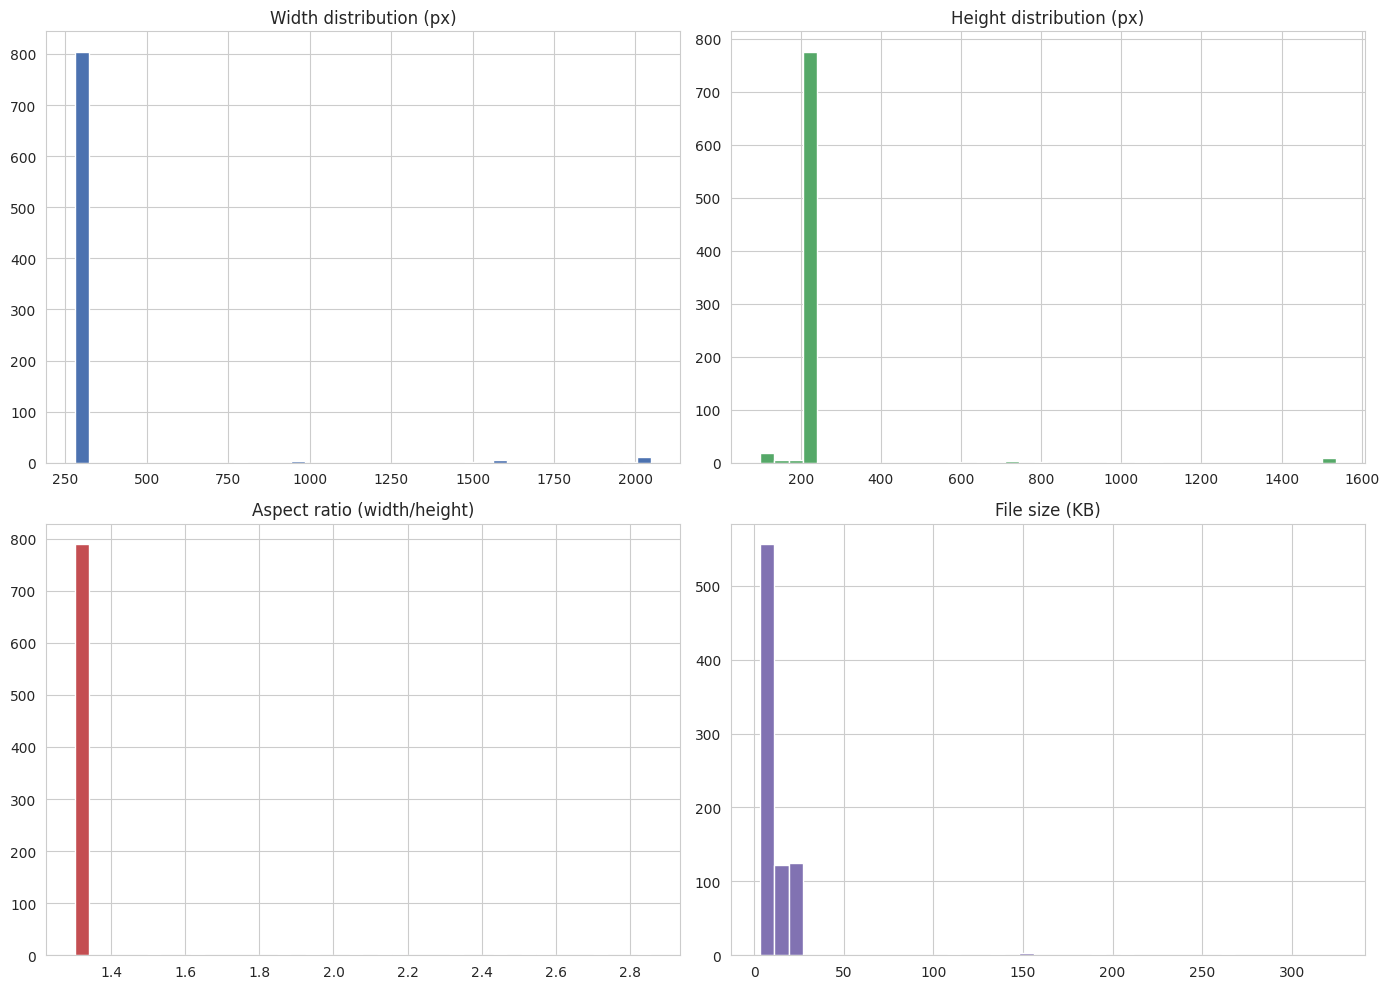

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes[0,0].hist(valid_df['width'], bins=40, color='#4C72B0')
axes[0,0].set_title('Width distribution (px)')

axes[0,1].hist(valid_df['height'], bins=40, color='#55A868')
axes[0,1].set_title('Height distribution (px)')

axes[1,0].hist(valid_df['aspect_ratio'], bins=40, color='#C44E52')
axes[1,0].set_title('Aspect ratio (width/height)')

axes[1,1].hist(valid_df['size_kb'], bins=40, color='#8172B2')
axes[1,1].set_title('File size (KB)')

plt.tight_layout()
plt.show()

In [24]:
print('Combined numeric summary:')
valid_df[['width','height','aspect_ratio','size_kb']].describe()

Combined numeric summary:


,width,height,aspect_ratio,size_kb
count,827.000000,827.000000,827.000000,827.000000
mean,318.973398,231.228537,1.372724,15.276262
std,242.097747,157.139001,0.197455,29.408502
min,280.000000,98.000000,1.302326,3.112305
25%,280.000000,210.000000,1.333333,6.199219
50%,280.000000,210.000000,1.333333,8.004883
75%,280.000000,210.000000,1.333333,17.477051
max,2048.000000,1536.000000,2.857143,324.784180


In [25]:
print('Per-category median dimensions and file size:')
valid_df.groupby('category').agg(
    median_width=('width','median'),
    median_height=('height','median'),
    median_size_kb=('size_kb','median'),
    min_width=('width','min'),
    min_height=('height','min'),
    max_size_kb=('size_kb','max'),
).round(1)

Per-category median dimensions and file size:


,median_width,median_height,median_size_kb,min_width,min_height,max_size_kb
category,,,,,,
Automobiles,280.0,210.0,4.1,280,210,211.7
Freight Cars,280.0,210.0,8.1,280,98,268.1
Locomotives,280.0,210.0,7.8,280,109,324.8
Passenger Train Cars,280.0,210.0,8.4,280,210,148.2


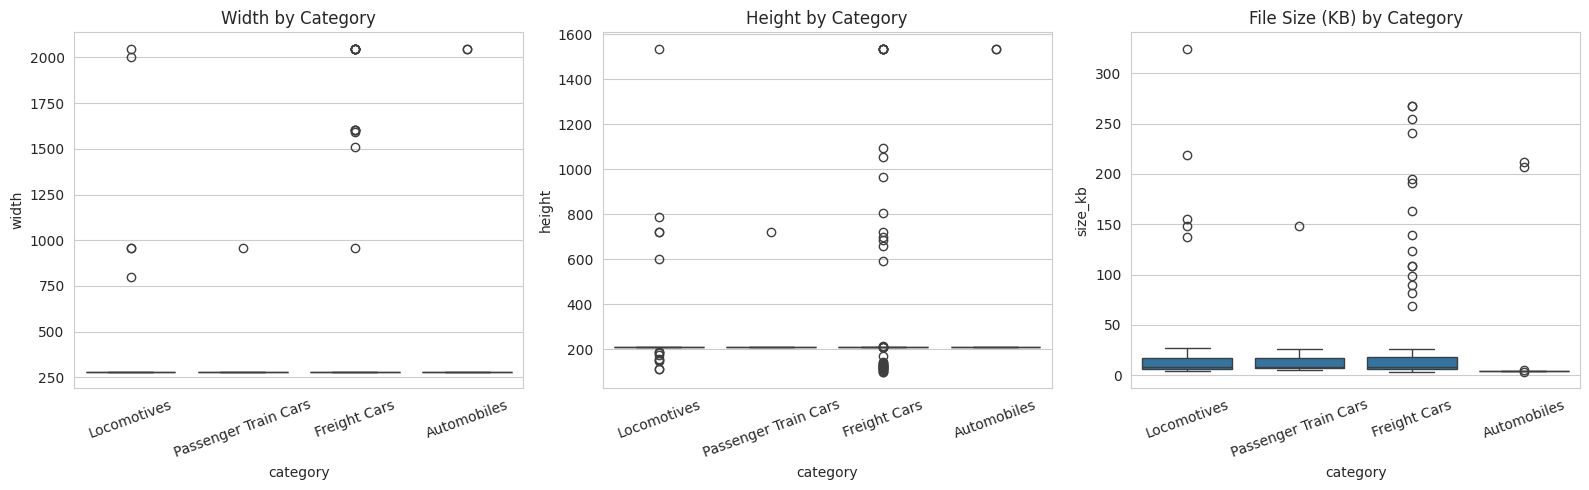

In [26]:
# Boxplots comparing categories directly
fig, axes = plt.subplots(1, 3, figsize=(16,5))

sns.boxplot(data=valid_df, x='category', y='width', ax=axes[0])
axes[0].set_title('Width by Category')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=valid_df, x='category', y='height', ax=axes[1])
axes[1].set_title('Height by Category')
axes[1].tick_params(axis='x', rotation=20)

sns.boxplot(data=valid_df, x='category', y='size_kb', ax=axes[2])
axes[2].set_title('File Size (KB) by Category')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 8. Duplicate Image Detection

Uses an MD5 hash of each file's exact byte content. Flags two situations:
- **Same image used for two different products** (mislabeling risk — actively harmful to training)
- **Exact duplicate files within the same product folder** (harmless but wasteful, worth cleaning up)

In [27]:
def file_md5(path, chunk_size=65536):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            h.update(chunk)
    return h.hexdigest()

valid_df['md5'] = valid_df['path'].apply(file_md5)
print(f"Computed MD5 hash for {len(valid_df)} images.")

Computed MD5 hash for 827 images.


In [28]:
hash_groups = valid_df.groupby('md5')
duplicate_hashes = [h for h, g in hash_groups if len(g) > 1]
print(f"Duplicate hash groups (same exact file appears more than once): {len(duplicate_hashes)}")

Duplicate hash groups (same exact file appears more than once): 12


In [29]:
cross_product_dupes = []
within_product_dupes = []

for h in duplicate_hashes:
    group = valid_df[valid_df['md5'] == h]
    unique_products = group[['category','products_id']].drop_duplicates()
    if len(unique_products) > 1:
        cross_product_dupes.append(group)
    else:
        within_product_dupes.append(group)

print(f"⚠️ Cross-product duplicates (SAME image under DIFFERENT products_id — investigate!): {len(cross_product_dupes)} group(s)")
print(f"Within-product duplicates (same image saved twice for the same item — harmless): {len(within_product_dupes)} group(s)")

⚠️ Cross-product duplicates (SAME image under DIFFERENT products_id — investigate!): 12 group(s)
Within-product duplicates (same image saved twice for the same item — harmless): 0 group(s)


In [30]:
if cross_product_dupes:
    print('Cross-product duplicate details:')
    for g in cross_product_dupes:
        display(g[['category','products_id','catalog_name','filename']])
else:
    print('✅ No image is shared across two different products — labeling looks clean.')

Cross-product duplicate details:


,category,products_id,catalog_name,filename
558,Freight Cars,1265,651. Great Norther Box Car #27017,1265.jpeg
608,Freight Cars,1442,724. Great Norther Box Car #27017,1442.jpeg


,category,products_id,catalog_name,filename
340,Passenger Train Cars,1155,504. Norfolk Western Coach Car1,1155.jpg
402,Passenger Train Cars,1524,510. Norfolk Western Coach Car3,1524.jpg


,category,products_id,catalog_name,filename
370,Passenger Train Cars,1193,627. Milwaukee Road Hiawatha Diner Car #109,1193.jpg
371,Passenger Train Cars,1194,627. Milwaukee Road Hiawatha Diner Car #109,1194.jpg
372,Passenger Train Cars,1195,627. Milwaukee Road Hiawatha Diner Car #109,1195.jpg
373,Passenger Train Cars,1196,627. Milwaukee Road Hiawatha Diner Car #109,1196.jpg


,category,products_id,catalog_name,filename
689,Freight Cars,1748,Union Pacific double-door boxcar 6-17208-2.jpg,1748.jpg
690,Freight Cars,1758,Union Pacific double-door boxcar 6-17208.jpg,1758.jpg


...

,category,products_id,catalog_name,filename
385,Passenger Train Cars,1418,703. Bachman No. 97207 Eureka & Palisade Passenger Car #Anna,1418.jpg
386,Passenger Train Cars,1419,704. Bachman No. 97207 Eureka & Palisade Passenger Car #Anna,1419.jpg


,category,products_id,catalog_name,filename
339,Passenger Train Cars,1154,503. Norfolk Western Pullman Sleeper Car1,1154.jpg
400,Passenger Train Cars,1522,508. Norfolk Western Sleeper Car3,1522.jpg
401,Passenger Train Cars,1523,509. Norfolk Western Sleeper Car4,1523.jpg


,category,products_id,catalog_name,filename
41,Locomotives,1212,643. Souther Pacific Daylight Locomotive & Engine #4458,1212.jpg
111,Locomotives,1526,642. Souther Pacific Daylight Locomotive & Tender without sound#4449,1526.jpg


,category,products_id,catalog_name,filename
693,Freight Cars,1768,1993 T.T.O.S. convention car 6-52010-2.jpg,1768.jpg
694,Freight Cars,1771,1993 T.T.O.S. convention car 6-52010.jpg,1771.jpg


,category,products_id,catalog_name,filename
146,Locomotives,1637,Midland 1000 4.4.0,1637.jpg
420,Passenger Train Cars,1636,Midland 1000 4.4.0,1636.jpg


## 9. Naming Sanity Checks

Looks for products with identical or near-identical catalog names — these are strong
candidates for visually near-identical items (e.g. two physical units of the same model),
which are exactly the cases where the classifier is most likely to get confused and where
extra training photos matter most.

In [31]:
name_counts = products_df.groupby(['category','catalog_name']).size().reset_index(name='count')
exact_dupes = name_counts[name_counts['count'] > 1].sort_values('count', ascending=False)

print(f"Product names that appear more than once (exact match): {len(exact_dupes)}")
exact_dupes

Product names that appear more than once (exact match): 4


,category,catalog_name,count
724,Passenger Train Cars,627. Milwaukee Road Hiawatha Diner Car #109,4
300,Freight Cars,Marklin Passenger Coach 5801,2
367,Locomotives,106. Lionel 400E Locomotive & Tender,2
668,Passenger Train Cars,111. American Flyer Academy 1-4391,2


In [32]:
if len(exact_dupes):
    print('Full detail on exact-duplicate-name products (likely look-alike pairs):')
    for _, row in exact_dupes.iterrows():
        matches = products_df[(products_df['category']==row['category']) & (products_df['catalog_name']==row['catalog_name'])]
        display(matches[['products_id','catalog_name','category']])

Full detail on exact-duplicate-name products (likely look-alike pairs):


,products_id,catalog_name,category
237,1193,627. Milwaukee Road Hiawatha Diner Car #109,Passenger Train Cars
238,1194,627. Milwaukee Road Hiawatha Diner Car #109,Passenger Train Cars
239,1195,627. Milwaukee Road Hiawatha Diner Car #109,Passenger Train Cars
240,1196,627. Milwaukee Road Hiawatha Diner Car #109,Passenger Train Cars


,products_id,catalog_name,category
494,1602,Marklin Passenger Coach 5801,Freight Cars
500,1608,Marklin Passenger Coach 5801,Freight Cars


,products_id,catalog_name,category
131,1079,106. Lionel 400E Locomotive & Tender,Locomotives
132,1080,106. Lionel 400E Locomotive & Tender,Locomotives


,products_id,catalog_name,category
137,1085,111. American Flyer Academy 1-4391,Passenger Train Cars
138,1086,111. American Flyer Academy 1-4391,Passenger Train Cars


In [33]:
# Fuzzy near-duplicate name check (catches things like '106. Lionel 400E' vs '106. Lionel 400E Locomotive')
def name_similarity(a, b):
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()

near_dupe_pairs = []
for category in CATEGORY_DIRS.keys():
    names = products_df[products_df['category']==category][['products_id','catalog_name']].dropna().values.tolist()
    for i in range(len(names)):
        for j in range(i+1, len(names)):
            pid_a, name_a = names[i]
            pid_b, name_b = names[j]
            if pid_a == pid_b:
                continue
            sim = name_similarity(name_a, name_b)
            if sim > 0.85:  # high similarity threshold, tune as needed
                near_dupe_pairs.append({'category': category, 'products_id_a': pid_a, 'name_a': name_a,
                                         'products_id_b': pid_b, 'name_b': name_b, 'similarity': round(sim,3)})

near_dupe_df = pd.DataFrame(near_dupe_pairs).sort_values('similarity', ascending=False) if near_dupe_pairs else pd.DataFrame()
print(f"Near-duplicate name pairs found (similarity > 0.85): {len(near_dupe_df)}")
near_dupe_df.head(30)

Near-duplicate name pairs found (similarity > 0.85): 229


,category,products_id_a,name_a,products_id_b,name_b,similarity
2,Locomotives,1079,106. Lionel 400E Locomotive & Tender,1080,106. Lionel 400E Locomotive & Tender,1.000
35,Locomotives,1685,Stock #4258C Carnation Milk Car reefer,1691,Stock #4258C Carnation Milk Car Reefer,1.000
91,Passenger Train Cars,1193,627. Milwaukee Road Hiawatha Diner Car #109,1195,627. Milwaukee Road Hiawatha Diner Car #109,1.000
95,Passenger Train Cars,1195,627. Milwaukee Road Hiawatha Diner Car #109,1196,627. Milwaukee Road Hiawatha Diner Car #109,1.000
56,Passenger Train Cars,1085,111. American Flyer Academy 1-4391,1086,111. American Flyer Academy 1-4391,1.000
92,Passenger Train Cars,1193,627. Milwaukee Road Hiawatha Diner Car #109,1196,627. Milwaukee Road Hiawatha Diner Car #109,1.000
90,Passenger Train Cars,1193,627. Milwaukee Road Hiawatha Diner Car #109,1194,627. Milwaukee Road Hiawatha Diner Car #109,1.000
93,Passenger Train Cars,1194,627. Milwaukee Road Hiawatha Diner Car #109,1195,627. Milwaukee Road Hiawatha Diner Car #109,1.000
94,Passenger Train Cars,1194,627. Milwaukee Road Hiawatha Diner Car #109,1196,627. Milwaukee Road Hiawatha Diner Car #109,1.000
187,Freight Cars,1602,Marklin Passenger Coach 5801,1608,Marklin Passenger Coach 5801,1.000


**Why this matters:** every pair listed above is a strong candidate for a visually
confusable pair once the model is trained. These are exactly the items worth
prioritizing for extra reshoot photos (multiple angles) before or shortly after
the first training run — see Section 12 (Final Readiness Summary) for a consolidated
priority list.

## 10. Failed Downloads Analysis

Items listed on the live site whose image could not be downloaded/validated by the
scraper. These currently have **zero training images** and need attention before
the model can ever recognize them.

In [34]:
if len(failed_df):
    print(f"Total failed: {len(failed_df)}")
    print()
    print('By category:')
    print(failed_df['category'].value_counts())
    print()
    display(failed_df)
else:
    print('✅ No entries in failed_downloads.csv.')

Total failed: 11

By category:
category
Locomotives     9
Freight Cars    2
Name: count, dtype: int64



,products_id,catalog_name,category,image_url_or_reason
0,1574,LGB Box Cars (2) P&O + LGB 5057,Locomotives,images/LGB Box Cars (2) P&O + LGB 5057.jpg
1,1541,LGB diesel-locomotive Nichtraucher 2,Locomotives,images/LGB diesel-locomotive Nichtraucher 2.jpg
2,1543,LGB Rottenfahrzeug Nur für Nebenstrecken,Locomotives,images/LGB Rottenfahrzeug Nur für Nebenstrecken.jpg
3,1709,#326 C-16 DENVER & RIO GRANDE,Locomotives,bmz_cache/3/326-c-16-denver-rio-grandejpg.image.280x210.jpg
4,1858,F-3 A PWR comp texas special,Locomotives,images/F-3-A-PWR-comp-texas-special.jpg
5,1857,F.M. Trainmaster post war N.J.C. 6-18321,Locomotives,images/FM-Trainmaster-post-war-NJC-6-18321.jpg
6,1732,Lionel Classics Passenger Car Set Piece 1,Locomotives,images/Lionel-Classics-Passenger-Car-Set-1.jpg
7,1787,Norfork Southern Dash 8 40-C 6-18213,Locomotives,bmz_cache/n/norfork-southern-dash-8-40-c-6-18213jpg.image.280x210.jpg
8,1772,Santa De Dash 8 40-B 6-18212,Locomotives,images/Santa-De-Dash-8-40-B-6-18212.jpg
9,1540,LGB diesel-locomotive Nichtraucher 2,Freight Cars,images/LGB diesel-locomotive Nichtraucher 2.jpg


In [35]:
# Cross-check: products listed with zero images on disk, whether or not they appear in failed_downloads.csv
listed_keys = set(zip(products_df['category'], products_df['products_id']))
has_image_keys = set(zip(images_df['category'], images_df['products_id']))
zero_image_keys = listed_keys - has_image_keys

zero_image_df = products_df[
    products_df.apply(lambda r: (r['category'], r['products_id']) in zero_image_keys, axis=1)
]

print(f"Products listed with ZERO images currently on disk: {len(zero_image_df)}")
zero_image_df[['products_id','catalog_name','category']]

Products listed with ZERO images currently on disk: 11


,products_id,catalog_name,category
428,1536,"LGB R, Vkabj Graines car",Freight Cars
432,1540,LGB diesel-locomotive Nichtraucher 2,Freight Cars
433,1541,LGB diesel-locomotive Nichtraucher 2,Locomotives
435,1543,LGB Rottenfahrzeug Nur für Nebenstrecken,Locomotives
466,1574,LGB Box Cars (2) P&O + LGB 5057,Locomotives
589,1709,#326 C-16 DENVER & RIO GRANDE,Locomotives
611,1732,Lionel Classics Passenger Car Set Piece 1,Locomotives
651,1772,Santa De Dash 8 40-B 6-18212,Locomotives
664,1787,Norfork Southern Dash 8 40-C 6-18213,Locomotives
734,1857,F.M. Trainmaster post war N.J.C. 6-18321,Locomotives


## 11. Azure Custom Vision Readiness Checks

Technical constraints that matter specifically for uploading into Azure Custom
Vision — catching anything that would be rejected or flagged at upload time,
before you get there.

In [36]:
# File size limit
oversized = valid_df[valid_df['size_kb'] > AZURE_MAX_FILE_SIZE_MB * 1024]
print(f"Images over Azure's {AZURE_MAX_FILE_SIZE_MB}MB file size limit: {len(oversized)}")
if len(oversized):
    display(oversized[['category','products_id','filename','size_kb']])

Images over Azure's 6MB file size limit: 0


In [37]:
# Minimum dimension check
undersized = valid_df[(valid_df['width'] < AZURE_MIN_DIMENSION) | (valid_df['height'] < AZURE_MIN_DIMENSION)]
print(f"Images below Azure's recommended {AZURE_MIN_DIMENSION}px minimum dimension: {len(undersized)}")
if len(undersized):
    display(undersized[['category','products_id','filename','width','height']])

Images below Azure's recommended 256px minimum dimension: 804


,category,products_id,filename,width,height
0,Locomotives,1030,1030.jpg,280,210
1,Locomotives,1031,1031.jpg,280,210
2,Locomotives,1035,1035.jpg,280,210
3,Locomotives,1044,1044.jpg,280,210
4,Locomotives,1048,1048.jpg,280,210
...,...,...,...,...,...
822,Automobiles,1917,1917.jpg,280,210
823,Automobiles,1925,1925.jpg,280,210
824,Automobiles,1926,1926.jpg,280,210
825,Automobiles,1965,1965.jpg,280,210


In [38]:
# Format check — Azure supports JPG, PNG, BMP, GIF
AZURE_SUPPORTED_FORMATS = {'JPEG','PNG','BMP','GIF'}
unsupported_format = valid_df[~valid_df['format'].isin(AZURE_SUPPORTED_FORMATS)]
print(f"Images in a format Azure Custom Vision does NOT support: {len(unsupported_format)}")
if len(unsupported_format):
    display(unsupported_format[['category','products_id','filename','format']])

Images in a format Azure Custom Vision does NOT support: 0


In [39]:
print('===== AZURE READINESS SUMMARY =====')
print(f"✅ Total valid, correctly-formatted, correctly-sized images ready to upload: "
      f"{len(valid_df) - len(oversized) - len(undersized) - len(unsupported_format)}")
print(f"⚠️ Oversized (need compressing): {len(oversized)}")
print(f"⚠️ Undersized (may hurt training quality): {len(undersized)}")
print(f"⚠️ Unsupported format (need converting): {len(unsupported_format)}")

===== AZURE READINESS SUMMARY =====
✅ Total valid, correctly-formatted, correctly-sized images ready to upload: 23
⚠️ Oversized (need compressing): 0
⚠️ Undersized (may hurt training quality): 804
⚠️ Unsupported format (need converting): 0


## 12. Visual Sample Grids — One Per Category

Random sample from each category to eyeball photo quality, background consistency,
and framing directly.

In [42]:
def show_category_sample(category, n=12, seed=42):
    cat_df = valid_df[valid_df['category'] == category]
    if len(cat_df) == 0:
        print(f"No valid images for {category}")
        return
    sample = cat_df.sample(n=min(n, len(cat_df)), random_state=seed)
    cols = 4
    rows = -(-len(sample) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
    axes = axes.flatten() if rows > 1 else [axes] if cols==1 else axes
    for ax, (_, row) in zip(np.array(axes).flatten(), sample.iterrows()):
        try:
            with Image.open(row['path']) as img:
                ax.imshow(img)
            title = f"{row['products_id']}"
            ax.set_title(title, fontsize=9)
        except Exception:
            ax.set_title('load failed', fontsize=9, color='red')
        ax.axis('off')
    for ax in np.array(axes).flatten()[len(sample):]:
        ax.axis('off')
    fig.suptitle(f'{category} — random sample', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

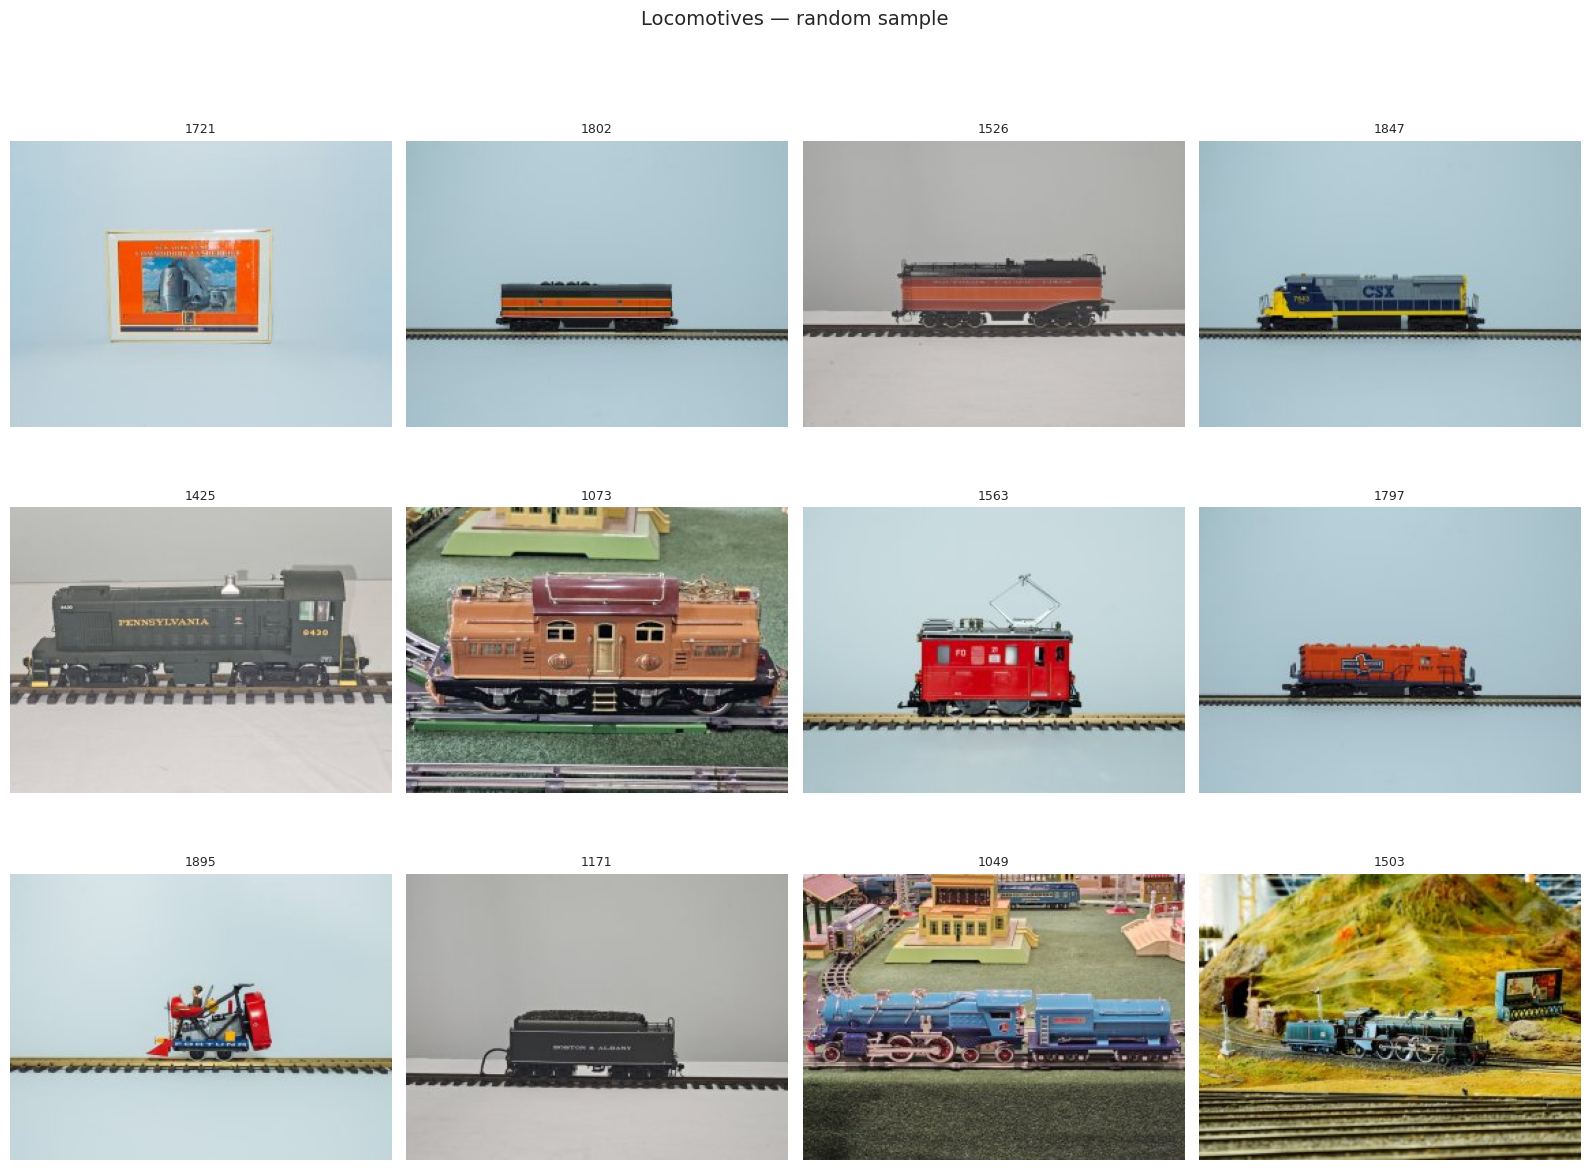

In [43]:
show_category_sample('Locomotives')

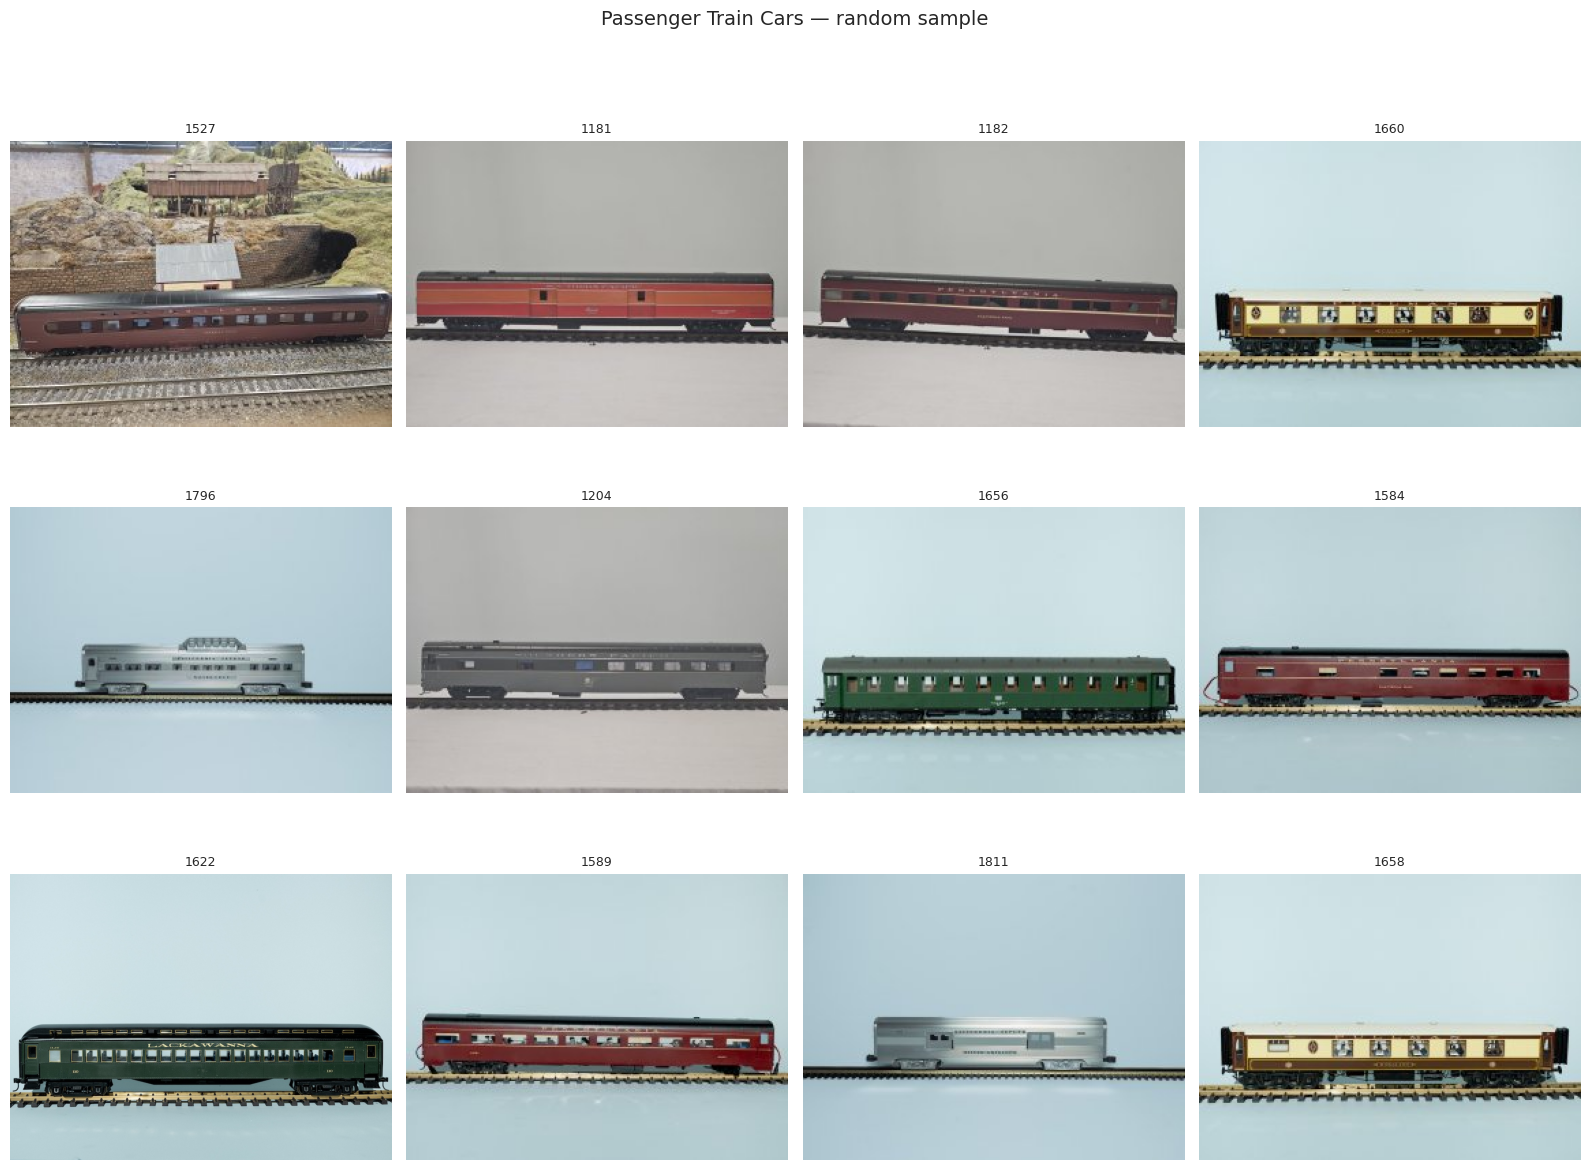

In [44]:
show_category_sample('Passenger Train Cars')

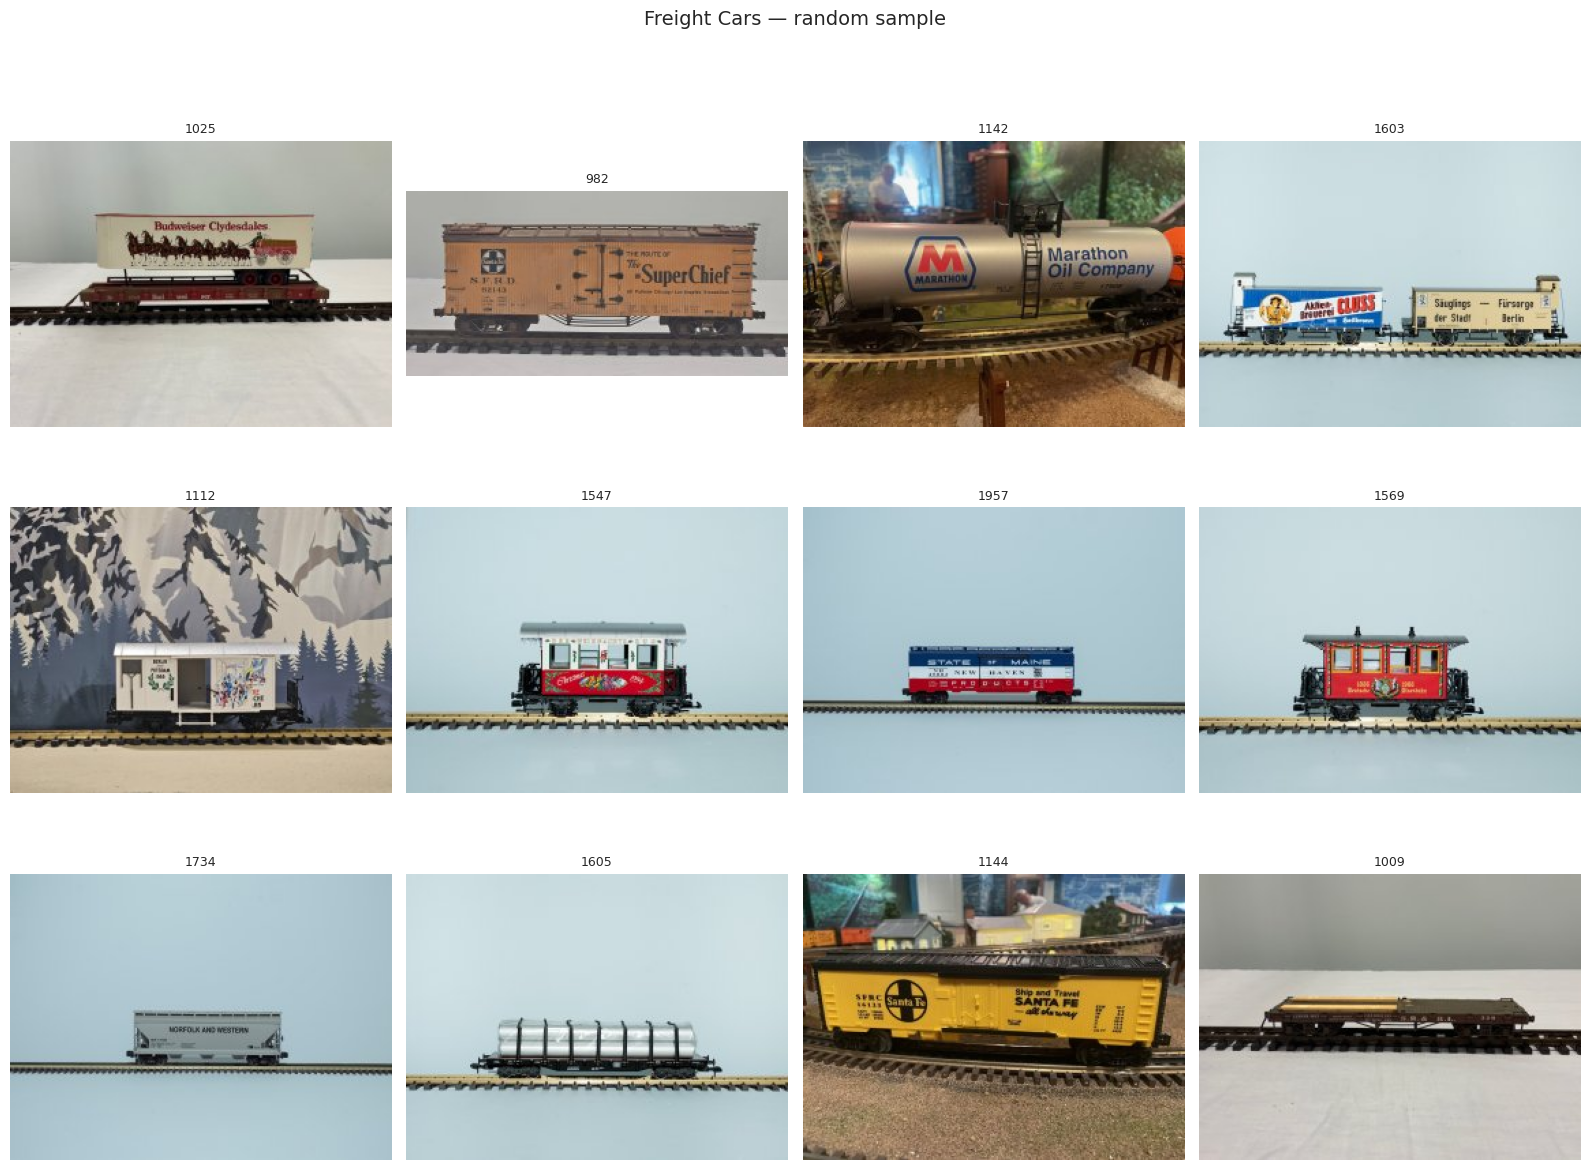

In [45]:
show_category_sample('Freight Cars')

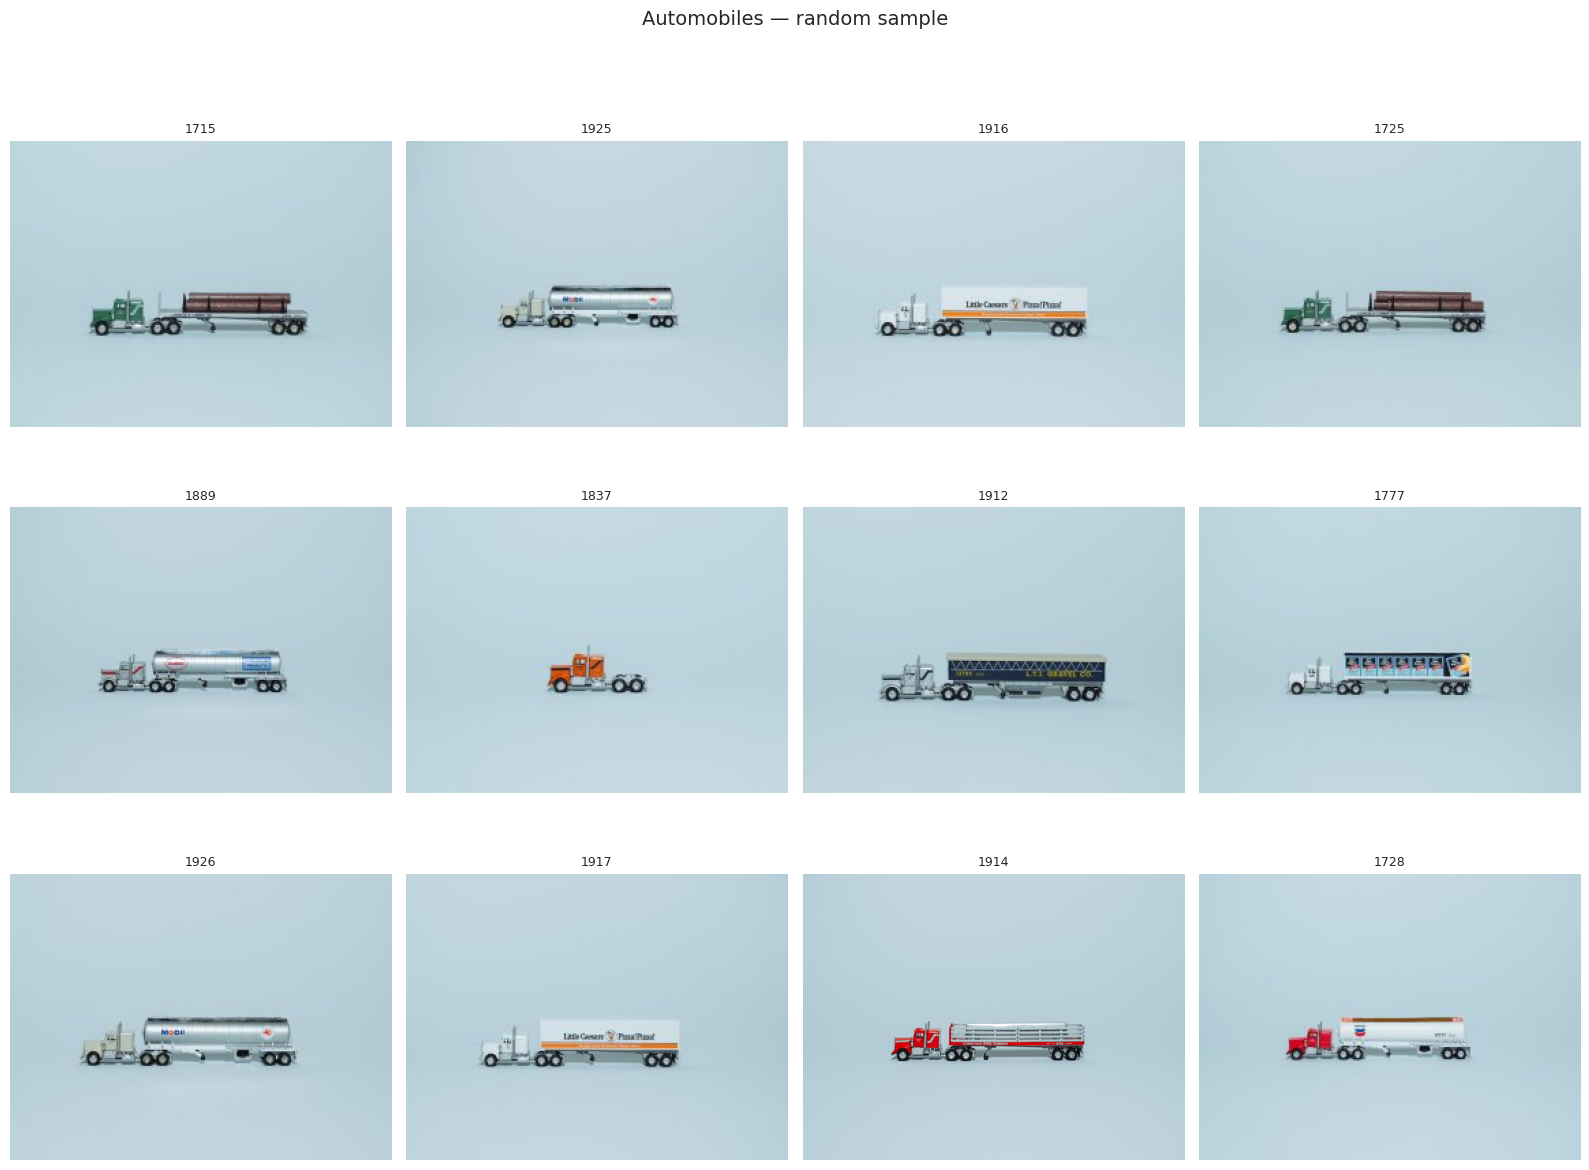

In [46]:
show_category_sample('Automobiles')

## 13. Final Readiness Summary

Consolidated, plain-language recap of everything above — what's ready, what needs
attention, and a priority action list before training starts.

In [47]:
print('='*70)
print('CONDUCTOR.FUN INVENTORY DATASET — FINAL READINESS SUMMARY')
print('='*70)
print()
print(f"Total products listed:              {len(products_df)}")
print(f"Total products with >=1 image:      {total_items_with_images}")
print(f"Total products with ZERO images:    {len(zero_image_df)}")
print(f"Total valid images:                 {len(valid_df)}")
print(f"Corrupt/unreadable images excluded: {len(corrupt_df)}")
print(f"Cross-product duplicate images:     {len(cross_product_dupes)}")
print(f"Exact duplicate-name products:      {len(exact_dupes)}")
print(f"Near-duplicate-name pairs:          {len(near_dupe_df)}")
print(f"Products below Azure's absolute minimum ({AZURE_ABSOLUTE_MIN_IMAGES_PER_TAG} img/tag): {len(below_absolute_min)}")
print(f"Products below Azure's RECOMMENDED minimum ({AZURE_MIN_RECOMMENDED_IMAGES_PER_TAG} img/tag): {len(below_recommended)}")
print(f"Oversized images (>{AZURE_MAX_FILE_SIZE_MB}MB):        {len(oversized)}")
print(f"Undersized images (<{AZURE_MIN_DIMENSION}px):        {len(undersized)}")
print(f"Unsupported format images:          {len(unsupported_format)}")
print()
print('--- Per category ---')
display(per_category_df)

CONDUCTOR.FUN INVENTORY DATASET — FINAL READINESS SUMMARY

Total products listed:              838
Total products with >=1 image:      827
Total products with ZERO images:    11
Total valid images:                 827
Corrupt/unreadable images excluded: 0
Cross-product duplicate images:     12
Exact duplicate-name products:      4
Near-duplicate-name pairs:          229
Products below Azure's absolute minimum (5 img/tag): 827
Products below Azure's RECOMMENDED minimum (15 img/tag): 827
Oversized images (>6MB):        0
Undersized images (<256px):        804
Unsupported format images:          0

--- Per category ---


,Category,Listed,With >=1 Image,Zero Images,Total Images,Avg Images/Item,Failed Downloads
0,Locomotives,312,303,9,303,1.0,9
1,Passenger Train Cars,171,171,0,171,1.0,0
2,Freight Cars,334,332,2,332,1.0,2
3,Automobiles,21,21,0,21,1.0,0


In [48]:
print('PRIORITY ACTION LIST before/alongside training:')
print()
print(f"1. {len(zero_image_df)} product(s) have NO image at all — cannot be recognized until photographed.")
print(f"2. {len(corrupt_df)} corrupt image(s) should be re-downloaded or removed.")
print(f"3. {len(cross_product_dupes)} cross-product duplicate image(s) need manual review — likely a labeling error.")
print(f"4. {len(below_absolute_min)} product(s) are below Azure's hard minimum and may fail to train as a tag at all.")
print(f"5. {len(near_dupe_df)} near-identical-name pair(s) — prioritize these for extra reshoot photos first,")
print(f"   since they're the most likely to be visually confused by the model.")
print(f"6. {len(oversized) + len(undersized) + len(unsupported_format)} image(s) need a format/size fix before Azure upload.")
print()
print('Everything else is ready to go as-is for a first training pass.')

PRIORITY ACTION LIST before/alongside training:

1. 11 product(s) have NO image at all — cannot be recognized until photographed.
2. 0 corrupt image(s) should be re-downloaded or removed.
3. 12 cross-product duplicate image(s) need manual review — likely a labeling error.
4. 827 product(s) are below Azure's hard minimum and may fail to train as a tag at all.
5. 229 near-identical-name pair(s) — prioritize these for extra reshoot photos first,
   since they're the most likely to be visually confused by the model.
6. 804 image(s) need a format/size fix before Azure upload.

Everything else is ready to go as-is for a first training pass.


In [49]:
# Export a clean, ready-to-use manifest for the tagging/upload script
export_cols = ['category','products_id','catalog_name','filename','path','width','height',
               'format','mode','size_kb','md5']
clean_manifest = valid_df[export_cols].copy()
clean_manifest.to_csv('clean_manifest.csv', index=False)
print(f"Exported clean_manifest.csv with {len(clean_manifest)} validated, ready-to-train image rows.")
clean_manifest.head()

Exported clean_manifest.csv with 827 validated, ready-to-train image rows.


,category,products_id,catalog_name,filename,path,width,height,format,mode,size_kb,md5
0,Locomotives,1030,41. Pacific Lumber Company,1030.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1030/1...,280,210,JPEG,RGB,12.047852,875447adc26dd912d19ba500cdcdfb97
1,Locomotives,1031,42. Pacific Lumber Company Climax Locomotive #PLMC No.2,1031.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1031/1...,280,210,JPEG,RGB,12.563477,1fa31273fd87e719c4db85cae6d1006c
2,Locomotives,1035,46. Pennsylvania 889,1035.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1035/1...,280,210,JPEG,RGB,8.625000,597817a41f86ad04ff375d1a81960aa1
3,Locomotives,1044,72. LIONEL I-384-E,1044.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1044/1...,280,210,JPEG,RGB,20.044922,81af3dbe9a692c8d2fcbecb203d901a0
4,Locomotives,1048,75. 2-400E locomotiv + tender,1048.jpg,/kaggle/input/datasets/datascientist97/locomotive-collection-inventory-images/Locomotives/1048/1...,280,210,JPEG,RGB,22.409180,ba5915165063f2af239b2d55e1e0643b
